## 기본 Tool 준비

In [1]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 95.8 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
# 이미 데이터는 다운로드 되어있으므로 다음 코드로 넘어간다


images_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Images')   # 이미지들이 위치한 폴더
mat_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map')   # 프로젝트 루트 디렉토리

# .mat 파일 경로 (train_list.mat와 test_list.mat가 각각 같은 구조라고 가정)
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# train_mat와 test_mat 내부에 'file_list'와 'labels' 등이 있음
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

# 최종적으로 ImageFolder 구조로 재구성할 대상 폴더 생성 (예: stanford_dogs/train, stanford_dogs/test)
base_dir = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir(예: train 혹은 test)에 클래스별 폴더를 생성하고 이미지를 복사합니다.
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):
        # file_list_array[idx]는 보통 array([<파일경로>]) 형태입니다.
        # 따라서, array([<파일경로>]).item()을 사용하면 실제 문자열을 얻을 수 있습니다.
        file_path = file_list_array[idx][0].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 파일 경로 예시: 'n02116738-African_hunting_dog/n02116738_2988.jpg'
        # 클래스 이름은 파일 경로의 최상위 폴더명 (예: 'n02116738-African_hunting_dog')
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 경로: Images 폴더 아래에 file_path 위치
        src_path = os.path.join(images_dir, file_path)
        # 대상 이미지 경로: dest_folder 아래에 원본 파일명 그대로 복사
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")

Processing train set...
Processing test set...
Dataset reorganization complete.


In [6]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [8]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

Label index: 100
Class name: n02110627-affenpinscher


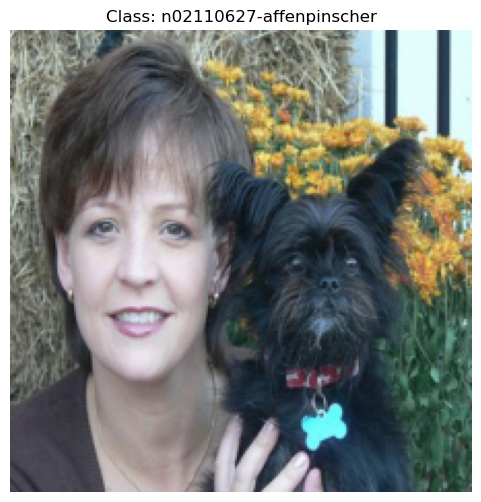

In [15]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
train_sample = train_dataset[10000]

visualize(train_sample)

Label index: 0
Class name: n02085620-Chihuahua


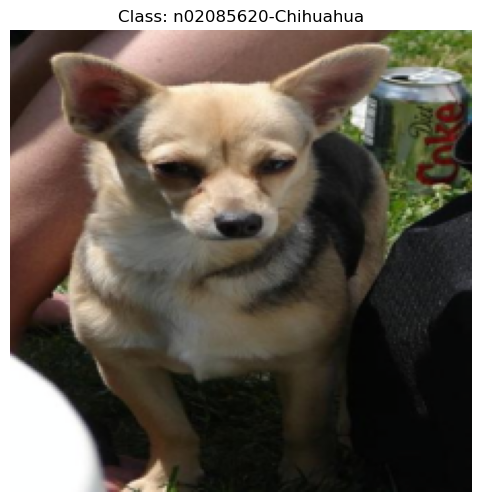

In [10]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
test_sample = valid_dataset[0]

visualize(test_sample)

In [16]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation/n02085620-Chihuahua/n02085620_10074')


# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


In [17]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [20]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [21]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2)


Epoch 1/2 시작
  Step 50 - Loss: 3.8836
  Step 100 - Loss: 5.0204
  Step 150 - Loss: 3.3517
  Step 200 - Loss: 3.2608
  Step 250 - Loss: 3.3700
  Step 300 - Loss: 2.9254
  Step 350 - Loss: 3.2192
  Step 400 - Loss: 3.0209
  Step 450 - Loss: 2.9993
  Step 500 - Loss: 2.3936
  Step 550 - Loss: 3.1476
  Step 600 - Loss: 2.3734
  Step 650 - Loss: 2.8073
  Step 700 - Loss: 2.9831
  Step 750 - Loss: 3.5398
  Step 800 - Loss: 3.2599
  Step 850 - Loss: 3.2800
  Step 900 - Loss: 3.6480
  Step 950 - Loss: 2.9755
  Step 1000 - Loss: 2.5648
Train - Loss: 3.2305, Accuracy: 22.07%
Validation - Loss: 3.3356, Accuracy: 24.83%

Epoch 2/2 시작
  Step 50 - Loss: 1.8138
  Step 100 - Loss: 1.9434
  Step 150 - Loss: 2.5342
  Step 200 - Loss: 2.4762
  Step 250 - Loss: 2.4677
  Step 300 - Loss: 3.0013
  Step 350 - Loss: 2.2915
  Step 400 - Loss: 1.5149
  Step 450 - Loss: 2.1702
  Step 500 - Loss: 2.0561
  Step 550 - Loss: 2.6764
  Step 600 - Loss: 2.1172
  Step 650 - Loss: 1.8979
  Step 700 - Loss: 1.8062
  Step

In [22]:
# 캠모델 저장

cam_model_path = os.path.join(os.getenv("HOME"), "work/class_activation_map/cam_model.pt")

torch.save(model, cam_model_path)

In [23]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

## 학습된 모델로 cam 생성

In [24]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [25]:
model = torch.load(cam_model_path, weights_only=False)

In [26]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [27]:
cam = generate_cam(model, sample_image)

In [28]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

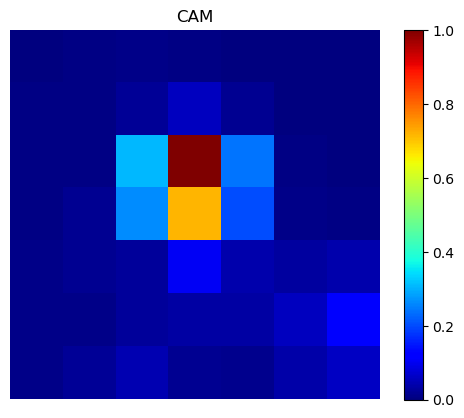

In [29]:
visualize_cam(cam)

In [30]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

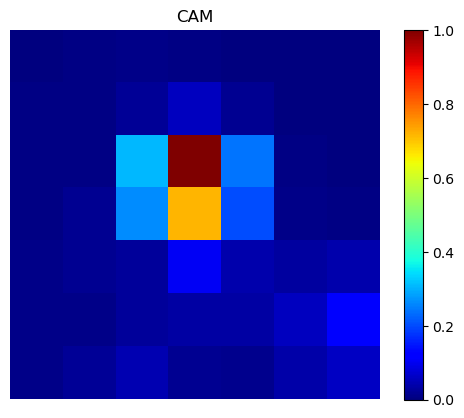

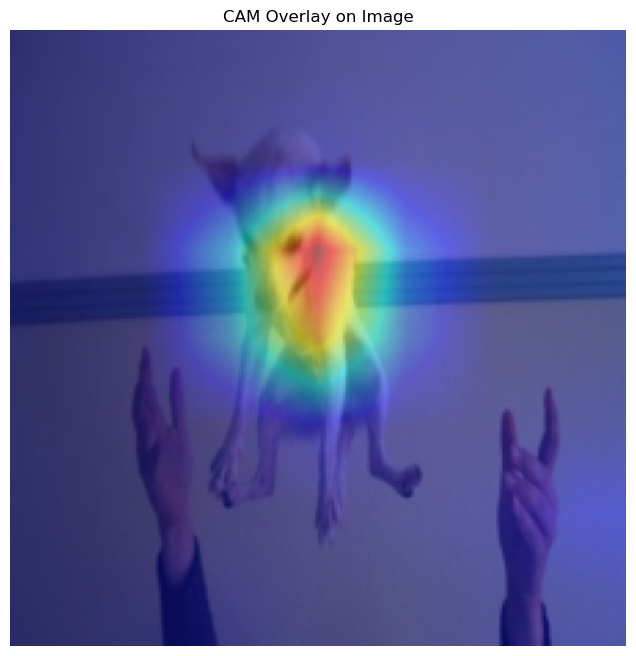

In [31]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

## 학습된 모델로 Grad-cam 생성

In [32]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


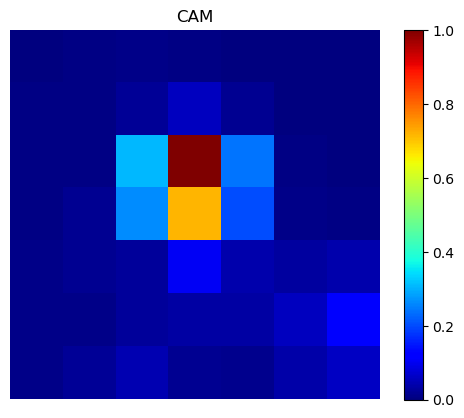

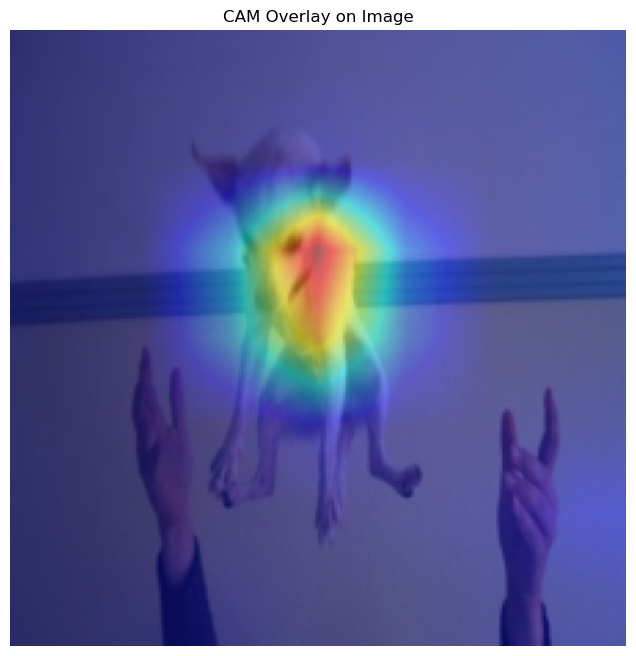

In [33]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

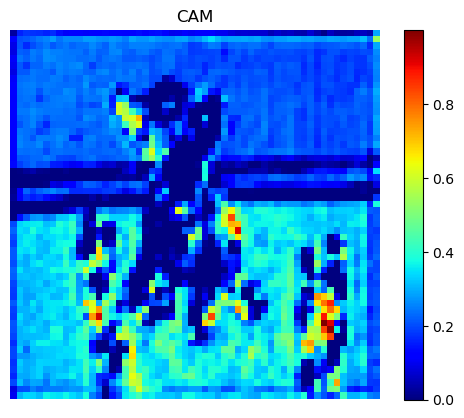

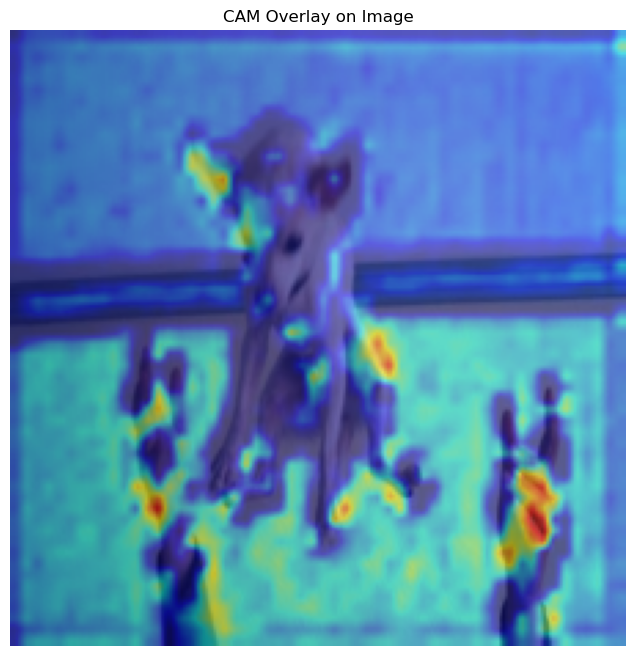

In [34]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

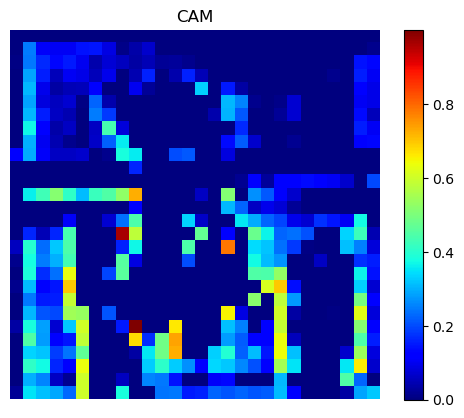

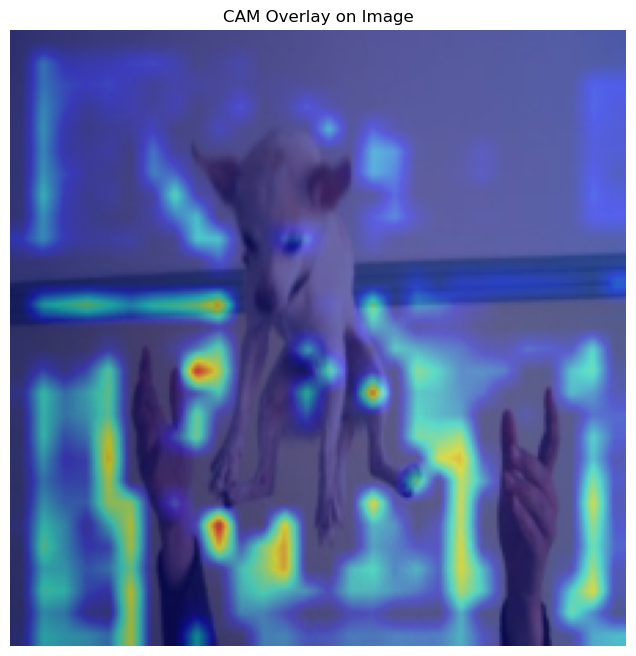

In [35]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer2")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

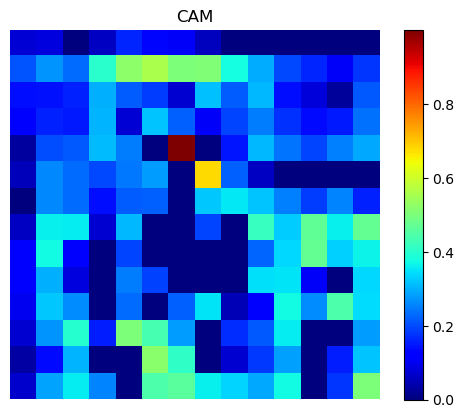

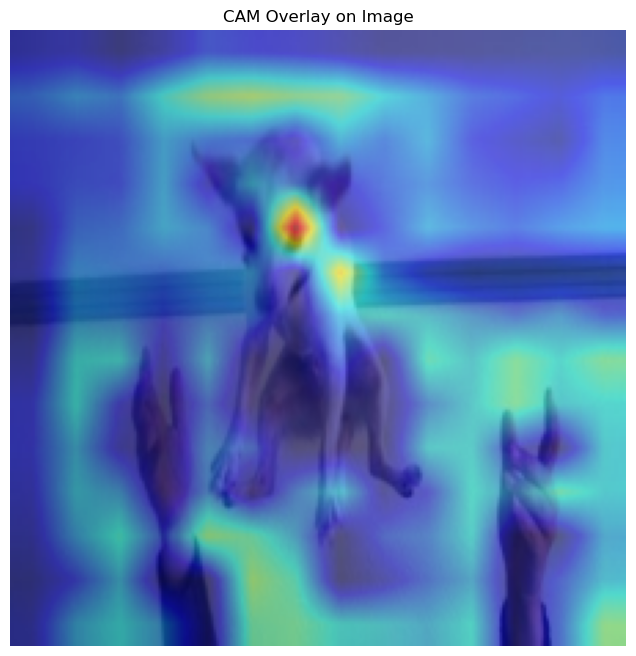

In [36]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

## 바운딩 박스 구하기

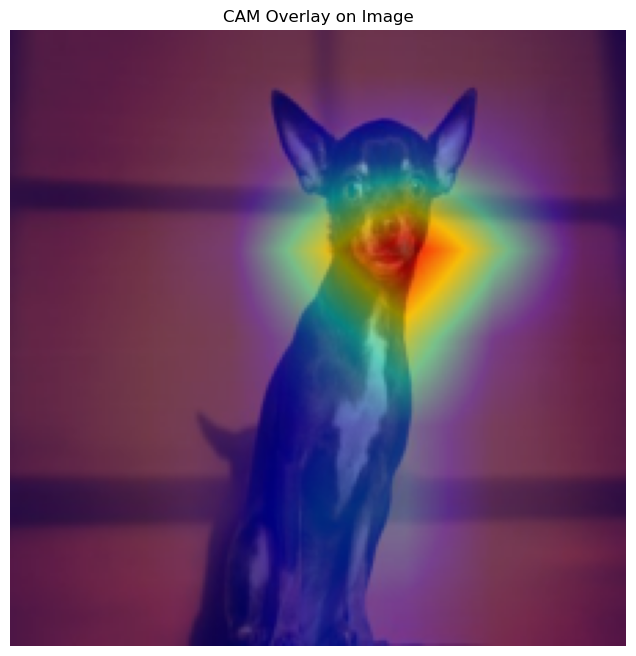

In [37]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [38]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [39]:
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(89), np.int64(63), np.int64(132), np.int64(122))


In [41]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

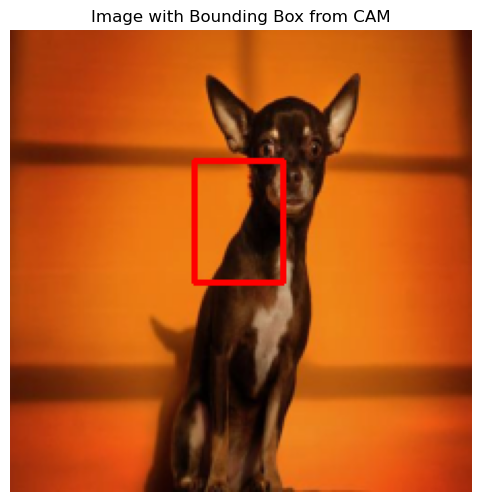

In [42]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

In [43]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

### IOU 구하기

In [44]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [45]:
get_iou(bbox, ground_bbox)

np.float64(0.13764615703359384)

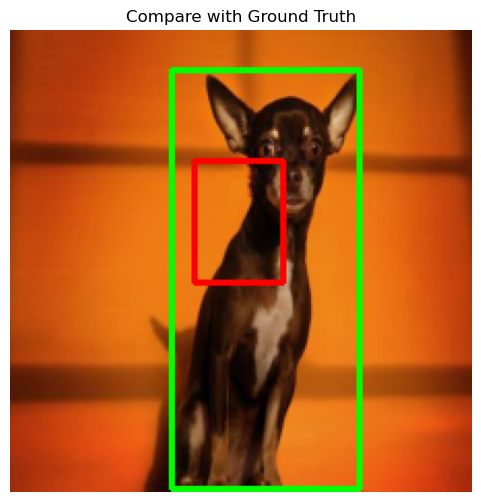

In [46]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

## 여러가지 실험을 통하여 cam과 grad-cam 성능비교

### 1. 사진을 심각하게 왜곡 시켜보기(grad-cam의 layer를 바꿔보며)

## grad-cam layer4

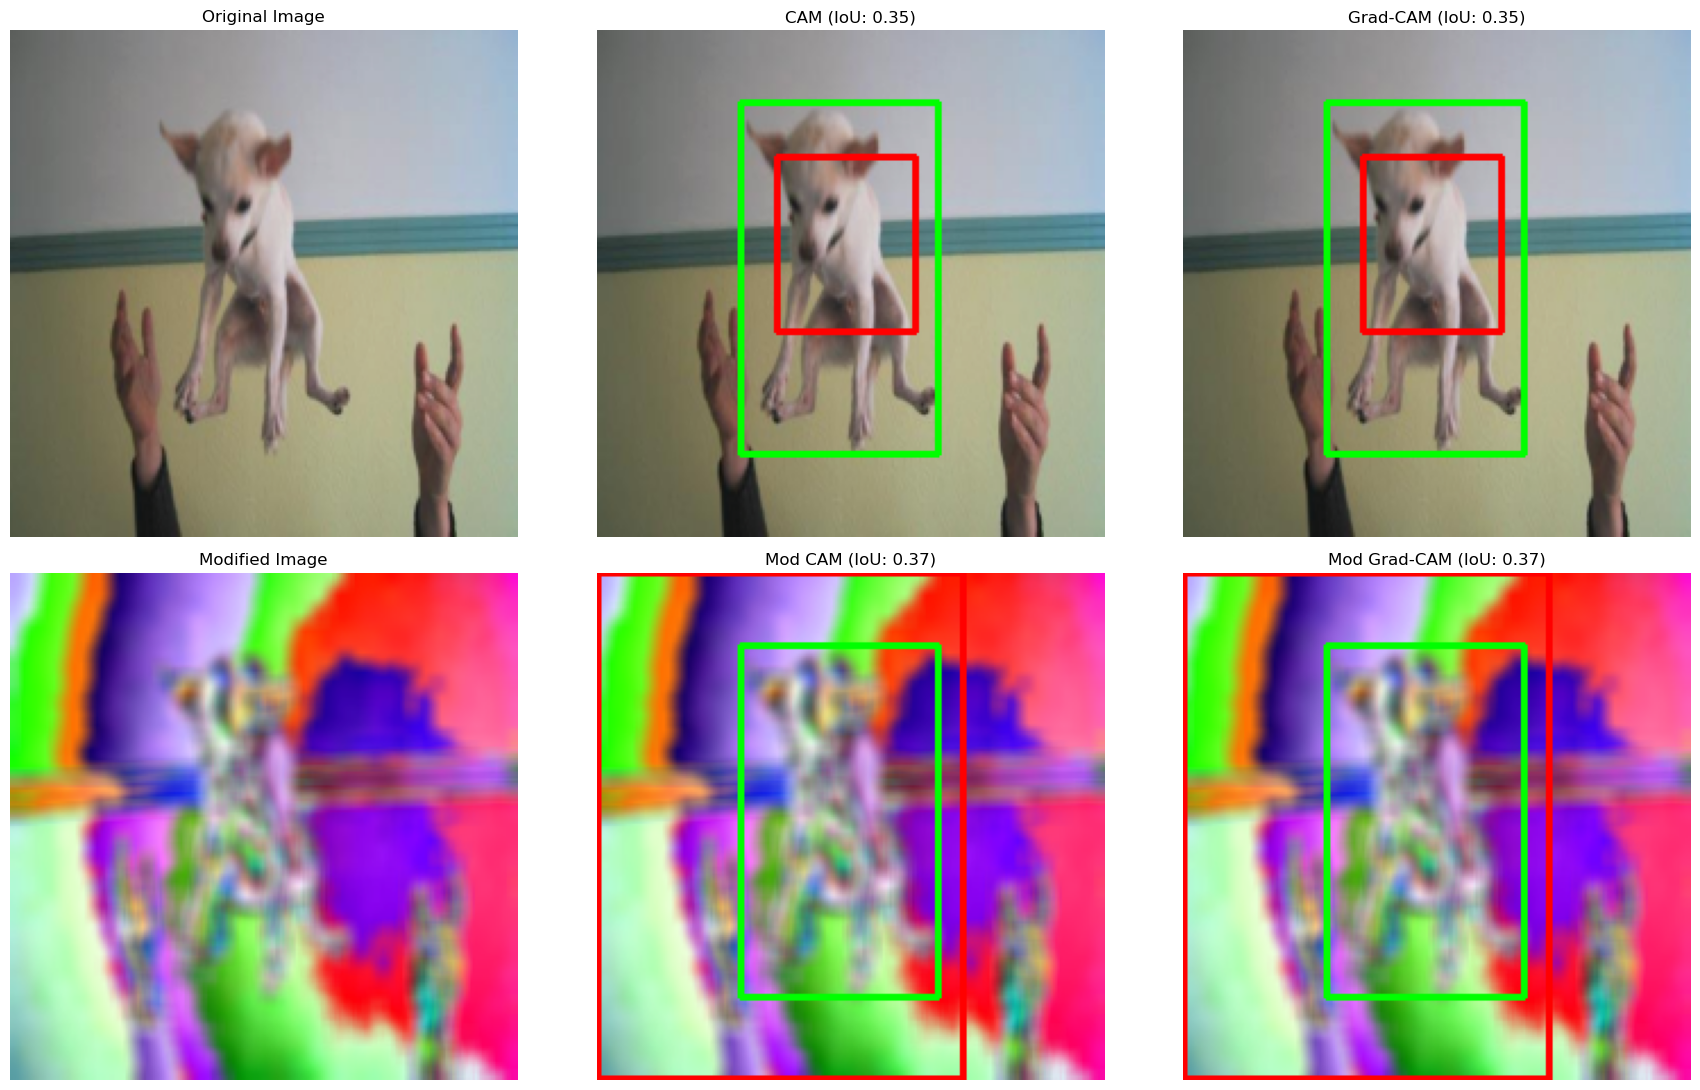

-------------------------------------------------------
Test Case            | CAM IoU      | Grad-CAM IoU
-------------------------------------------------------
Original             | 0.3491        | 0.3491
Background Mod       | 0.3747        | 0.3747
-------------------------------------------------------


In [50]:
# 1. 바운딩 박스 시각화 함수 (AI 예측: 파란색, 정답지: 초록색)
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    img_with_bbox = img.copy()
    
    # AI 인식 영역 (Blue) - 정수형 변환으로 OpenCV 에러 방지
    if bbox is not None:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    # 사람이 그린 정답지 (Green)
    if ground_truth is not None:
        x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
        cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

# 2. 성능 분석용 통합 테스트 함수 (Unpacking 에러 해결 버전)
def run_localization_test(img_tensor, target_bbox):
    # CAM/Grad-CAM 맵 생성 (layer4 기준)
    cam_map = generate_cam(model, img_tensor)
    grad_cam_map = generate_grad_cam(model, img_tensor, target_layer_name="layer4")
    
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    cam_resized = cv2.resize(cam_map, (w, h))
    grad_resized = cv2.resize(grad_cam_map, (w, h))
    
    # 바운딩 박스 추출 (Threshold 0.3)
    cam_bbox = get_bbox(cam_resized, threshold=0.3)
    grad_bbox = get_bbox(grad_resized, threshold=0.3)
    
    # IoU 계산
    cam_iou = get_iou(cam_bbox, target_bbox)
    grad_iou = get_iou(grad_bbox, target_bbox)
    
    # 결과 반환 (점수, 맵, 박스 좌표 묶음)
    return (cam_iou, grad_iou), (cam_resized, grad_resized), (cam_bbox, grad_bbox)

# 3. 데이터 준비 및 배경 왜곡 설정
confusing_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.3), 
    transforms.GaussianBlur(kernel_size=(9, 9), sigma=(2.0, 5.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 0번 데이터 인덱스 활용
image, label, ground_bbox = train_dataset[0]
orig_img = unnormalize(image)
gt_int = [int(x) for x in ground_bbox] # 정답지 정수화

# 모델 입력용 전처리
confused_tensor = confusing_transform(image)
confused_img_view = unnormalize(confused_tensor)
sample_image_orig = image.unsqueeze(0).to(device)
sample_image_confused = confused_tensor.unsqueeze(0).to(device)

# 4. 성능 테스트 실행
orig_scores, orig_maps, orig_bboxes = run_localization_test(sample_image_orig, ground_bbox)
conf_scores, conf_maps, conf_bboxes = run_localization_test(sample_image_confused, ground_bbox)

# 5. 최종 시각화 데이터 생성 (히트맵 + 박스 합성)
# 원본 CAM/Grad-CAM 결과에 박스 씌우기
res_orig_cam = visualize_both_bbox_on_image(orig_img, orig_bboxes[0], gt_int)
res_orig_grad = visualize_both_bbox_on_image(orig_img, orig_bboxes[1], gt_int)
# 왜곡된 CAM/Grad-CAM 결과에 박스 씌우기
res_conf_cam = visualize_both_bbox_on_image(confused_img_view, conf_bboxes[0], gt_int)
res_conf_grad = visualize_both_bbox_on_image(confused_img_view, conf_bboxes[1], gt_int)

# 6. 화면 출력
plt.figure(figsize=(18, 11))
titles = [
    "Original Image", f"CAM (IoU: {orig_scores[0]:.2f})", f"Grad-CAM (IoU: {orig_scores[1]:.2f})",
    "Modified Image", f"Mod CAM (IoU: {conf_scores[0]:.2f})", f"Mod Grad-CAM (IoU: {conf_scores[1]:.2f})"
]
display_images = [
    orig_img, res_orig_cam, res_orig_grad,
    confused_img_view, res_conf_cam, res_conf_grad
]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(display_images[i])
    plt.title(titles[i], fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 정량적 결과 출력
print("-" * 55)
print(f"{'Test Case':<20} | {'CAM IoU':<12} | {'Grad-CAM IoU':<12}")
print("-" * 55)
print(f"{'Original':<20} | {orig_scores[0]:.4f}        | {orig_scores[1]:.4f}")
print(f"{'Background Mod':<20} | {conf_scores[0]:.4f}        | {conf_scores[1]:.4f}")
print("-" * 55)

## grad-cam layer3

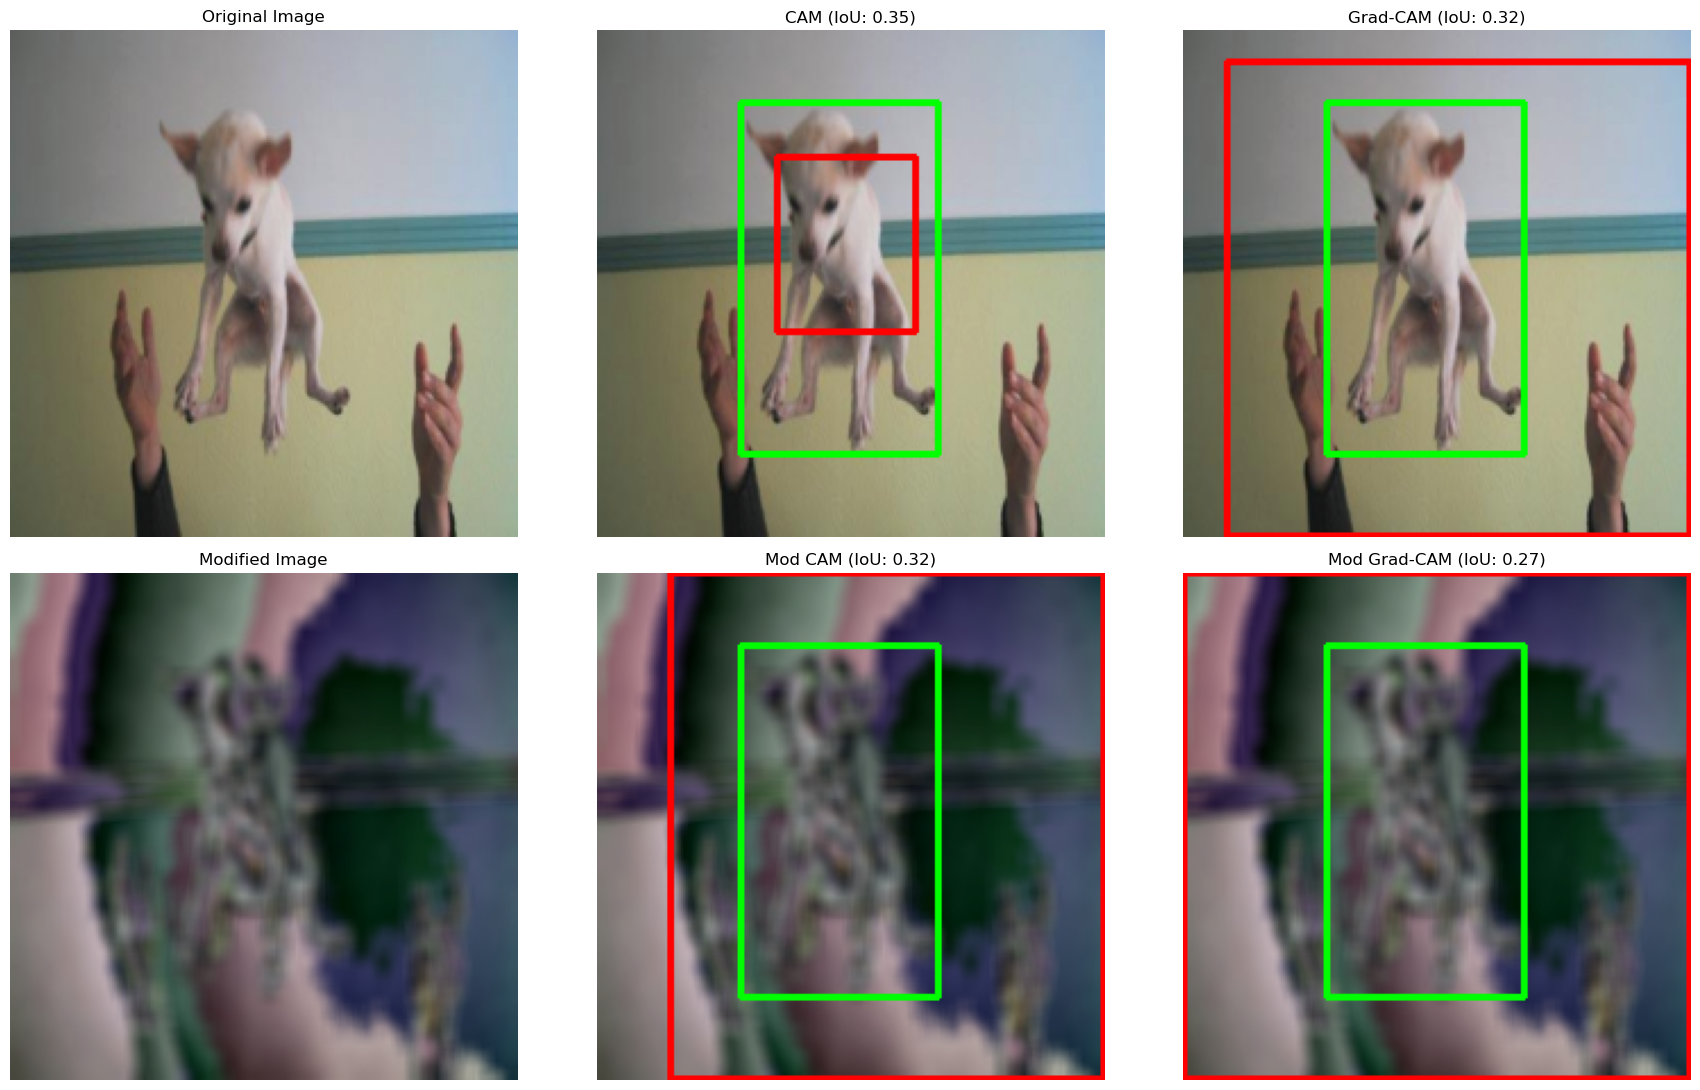

-------------------------------------------------------
Test Case            | CAM IoU      | Grad-CAM IoU
-------------------------------------------------------
Original             | 0.3491        | 0.3155
Background Mod       | 0.3159        | 0.2705
-------------------------------------------------------


In [52]:
# 1. 바운딩 박스 시각화 함수 (AI 예측: 파란색, 정답지: 초록색)
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    img_with_bbox = img.copy()
    
    # AI 인식 영역 (Blue) - 정수형 변환으로 OpenCV 에러 방지
    if bbox is not None:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    # 사람이 그린 정답지 (Green)
    if ground_truth is not None:
        x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
        cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

# 2. 성능 분석용 통합 테스트 함수 (Unpacking 에러 해결 버전)
def run_localization_test(img_tensor, target_bbox):
    # CAM/Grad-CAM 맵 생성 (layer4 기준)
    cam_map = generate_cam(model, img_tensor)
    grad_cam_map = generate_grad_cam(model, img_tensor, target_layer_name="layer3")
    
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    cam_resized = cv2.resize(cam_map, (w, h))
    grad_resized = cv2.resize(grad_cam_map, (w, h))
    
    # 바운딩 박스 추출 (Threshold 0.3)
    cam_bbox = get_bbox(cam_resized, threshold=0.3)
    grad_bbox = get_bbox(grad_resized, threshold=0.3)
    
    # IoU 계산
    cam_iou = get_iou(cam_bbox, target_bbox)
    grad_iou = get_iou(grad_bbox, target_bbox)
    
    # 결과 반환 (점수, 맵, 박스 좌표 묶음)
    return (cam_iou, grad_iou), (cam_resized, grad_resized), (cam_bbox, grad_bbox)

# 3. 데이터 준비 및 배경 왜곡 설정
confusing_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.3), 
    transforms.GaussianBlur(kernel_size=(9, 9), sigma=(2.0, 5.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 0번 데이터 인덱스 활용
image, label, ground_bbox = train_dataset[0]
orig_img = unnormalize(image)
gt_int = [int(x) for x in ground_bbox] # 정답지 정수화

# 모델 입력용 전처리
confused_tensor = confusing_transform(image)
confused_img_view = unnormalize(confused_tensor)
sample_image_orig = image.unsqueeze(0).to(device)
sample_image_confused = confused_tensor.unsqueeze(0).to(device)

# 4. 성능 테스트 실행
orig_scores, orig_maps, orig_bboxes = run_localization_test(sample_image_orig, ground_bbox)
conf_scores, conf_maps, conf_bboxes = run_localization_test(sample_image_confused, ground_bbox)

# 5. 최종 시각화 데이터 생성 (히트맵 + 박스 합성)
# 원본 CAM/Grad-CAM 결과에 박스 씌우기
res_orig_cam = visualize_both_bbox_on_image(orig_img, orig_bboxes[0], gt_int)
res_orig_grad = visualize_both_bbox_on_image(orig_img, orig_bboxes[1], gt_int)
# 왜곡된 CAM/Grad-CAM 결과에 박스 씌우기
res_conf_cam = visualize_both_bbox_on_image(confused_img_view, conf_bboxes[0], gt_int)
res_conf_grad = visualize_both_bbox_on_image(confused_img_view, conf_bboxes[1], gt_int)

# 6. 화면 출력
plt.figure(figsize=(18, 11))
titles = [
    "Original Image", f"CAM (IoU: {orig_scores[0]:.2f})", f"Grad-CAM (IoU: {orig_scores[1]:.2f})",
    "Modified Image", f"Mod CAM (IoU: {conf_scores[0]:.2f})", f"Mod Grad-CAM (IoU: {conf_scores[1]:.2f})"
]
display_images = [
    orig_img, res_orig_cam, res_orig_grad,
    confused_img_view, res_conf_cam, res_conf_grad
]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(display_images[i])
    plt.title(titles[i], fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 정량적 결과 출력
print("-" * 55)
print(f"{'Test Case':<20} | {'CAM IoU':<12} | {'Grad-CAM IoU':<12}")
print("-" * 55)
print(f"{'Original':<20} | {orig_scores[0]:.4f}        | {orig_scores[1]:.4f}")
print(f"{'Background Mod':<20} | {conf_scores[0]:.4f}        | {conf_scores[1]:.4f}")
print("-" * 55)

### 2. 배경만 심각하게 왜곡 시켜보기(grad-cam 의 layer를 바꿔보며)

## grad-cam layer4


Condition            | CAM IoU         | Grad-CAM IoU   
-----------------------------------------------------------------
Original             | 0.3491          | 0.3491
Only BG Dist.        | 0.3640          | 0.3640



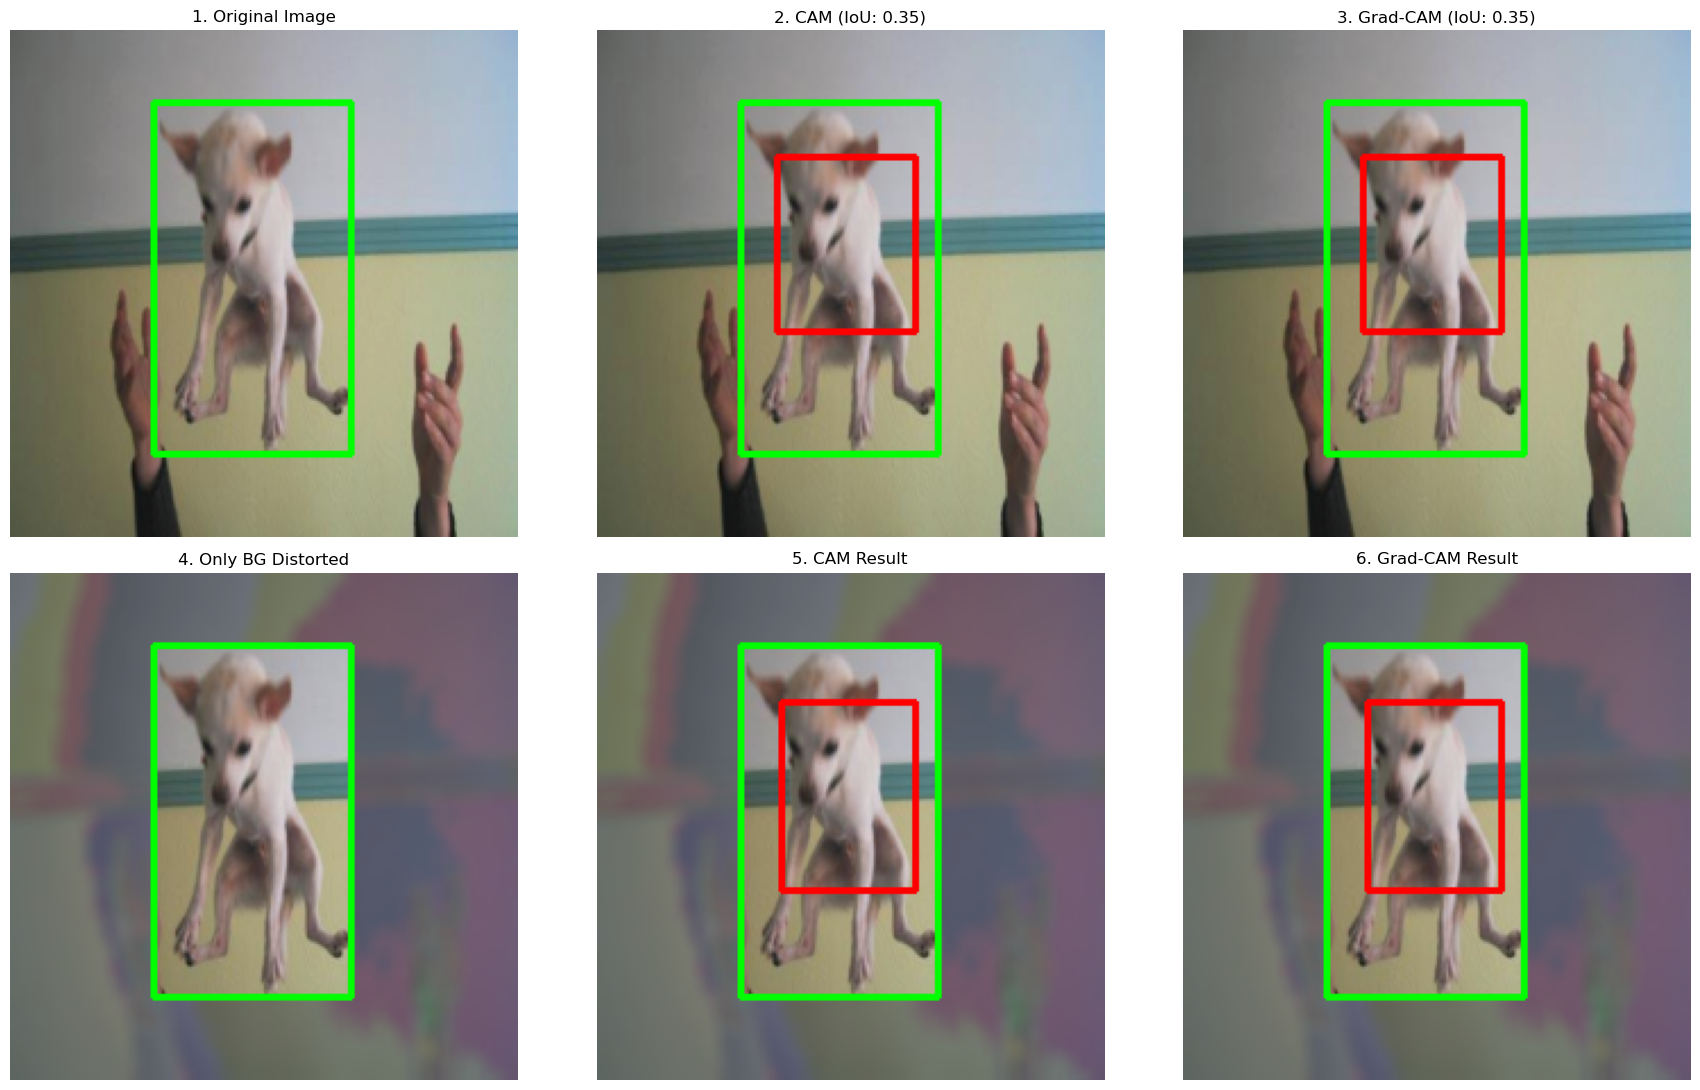

In [53]:
# --- 1. 바운딩 박스 시각화 함수 (Blue: AI, Green: 정답) ---
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    img_with_bbox = img.copy()
    
    # AI 인식 영역 (Blue) - 정수형 변환 필수
    if bbox is not None:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    # 사람이 그린 정답지 (Green)
    if ground_truth is not None:
        x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
        cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

# --- 2. 테스트 함수 (Unpacking 에러 방지를 위해 3개 그룹 반환) ---
def run_localization_test(img_tensor, target_bbox):
    # CAM/Grad-CAM 맵 생성 (layer4 기준)
    cam_map = generate_cam(model, img_tensor)
    grad_cam_map = generate_grad_cam(model, img_tensor, target_layer_name="layer4")
    
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    cam_resized = cv2.resize(cam_map, (w, h))
    grad_resized = cv2.resize(grad_cam_map, (w, h))
    
    # 바운딩 박스 추출 및 IoU 계산
    cam_bbox = get_bbox(cam_resized, threshold=0.3)
    grad_bbox = get_bbox(grad_resized, threshold=0.3)
    
    cam_iou = get_iou(cam_bbox, target_bbox)
    grad_iou = get_iou(grad_bbox, target_bbox)
    
    return (cam_iou, grad_iou), (cam_resized, grad_resized), (cam_bbox, grad_bbox)

# --- 3. 배경만 왜곡하는 함수 ---
def distort_background_only(image_tensor, bbox):
    confused_full = confusing_transform(image_tensor)
    x1, y1, x2, y2 = map(int, bbox)
    background_distorted = confused_full.clone()
    # 강아지 영역만 원본 데이터로 복구
    background_distorted[:, y1:y2, x1:x2] = image_tensor[:, y1:y2, x1:x2]
    return background_distorted

# --- 4. 데이터 준비 및 실험 실행 ---
image_tensor, label, ground_bbox = train_dataset[0] #
gt_int = [int(x) for x in ground_bbox]

# 배경만 왜곡된 텐서 생성
only_bg_confused_tensor = distort_background_only(image_tensor, ground_bbox)

# 시각화용 이미지 복원
orig_view = unnormalize(image_tensor)
confused_view = unnormalize(only_bg_confused_tensor)

# 모델 입력용 전송
sample_orig = image_tensor.unsqueeze(0).to(device)
sample_conf = only_bg_confused_tensor.unsqueeze(0).to(device)

# 테스트 실행 (반환값 3개 그룹)
orig_scores, orig_maps, orig_bboxes = run_localization_test(sample_orig, ground_bbox)
conf_scores, conf_maps, conf_bboxes = run_localization_test(sample_conf, ground_bbox)

# --- 5. 박스가 합성된 결과 이미지 생성 ---
# 원본 기준
res_orig_cam = visualize_both_bbox_on_image(orig_view, orig_bboxes[0], gt_int)
res_orig_grad = visualize_both_bbox_on_image(orig_view, orig_bboxes[1], gt_int)
# 배경 왜곡 기준
res_conf_input = visualize_both_bbox_on_image(confused_view, None, gt_int) # 입력이미지는 정답박스만
res_conf_cam = visualize_both_bbox_on_image(confused_view, conf_bboxes[0], gt_int)
res_conf_grad = visualize_both_bbox_on_image(confused_view, conf_bboxes[1], gt_int)

# --- 6. 최종 시각화 ---
print("\n" + "="*65)
print(f"{'Condition':<20} | {'CAM IoU':<15} | {'Grad-CAM IoU':<15}")
print("-"*65)
print(f"{'Original':<20} | {orig_scores[0]:.4f}          | {orig_scores[1]:.4f}")
print(f"{'Only BG Dist.':<20} | {conf_scores[0]:.4f}          | {conf_scores[1]:.4f}")
print("="*65 + "\n")

plt.figure(figsize=(18, 11))
titles = [
    "1. Original Image", f"2. CAM (IoU: {orig_scores[0]:.2f})", f"3. Grad-CAM (IoU: {orig_scores[1]:.2f})",
    "4. Only BG Distorted", "5. CAM Result", "6. Grad-CAM Result"
]
display_images = [
    visualize_both_bbox_on_image(orig_view, None, gt_int), res_orig_cam, res_orig_grad,
    res_conf_input, res_conf_cam, res_conf_grad
]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(display_images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## grad-cam layer3


Condition            | CAM IoU         | Grad-CAM IoU   
-----------------------------------------------------------------
Original             | 0.3491          | 0.3155
Only BG Dist.        | 0.3492          | 0.3613



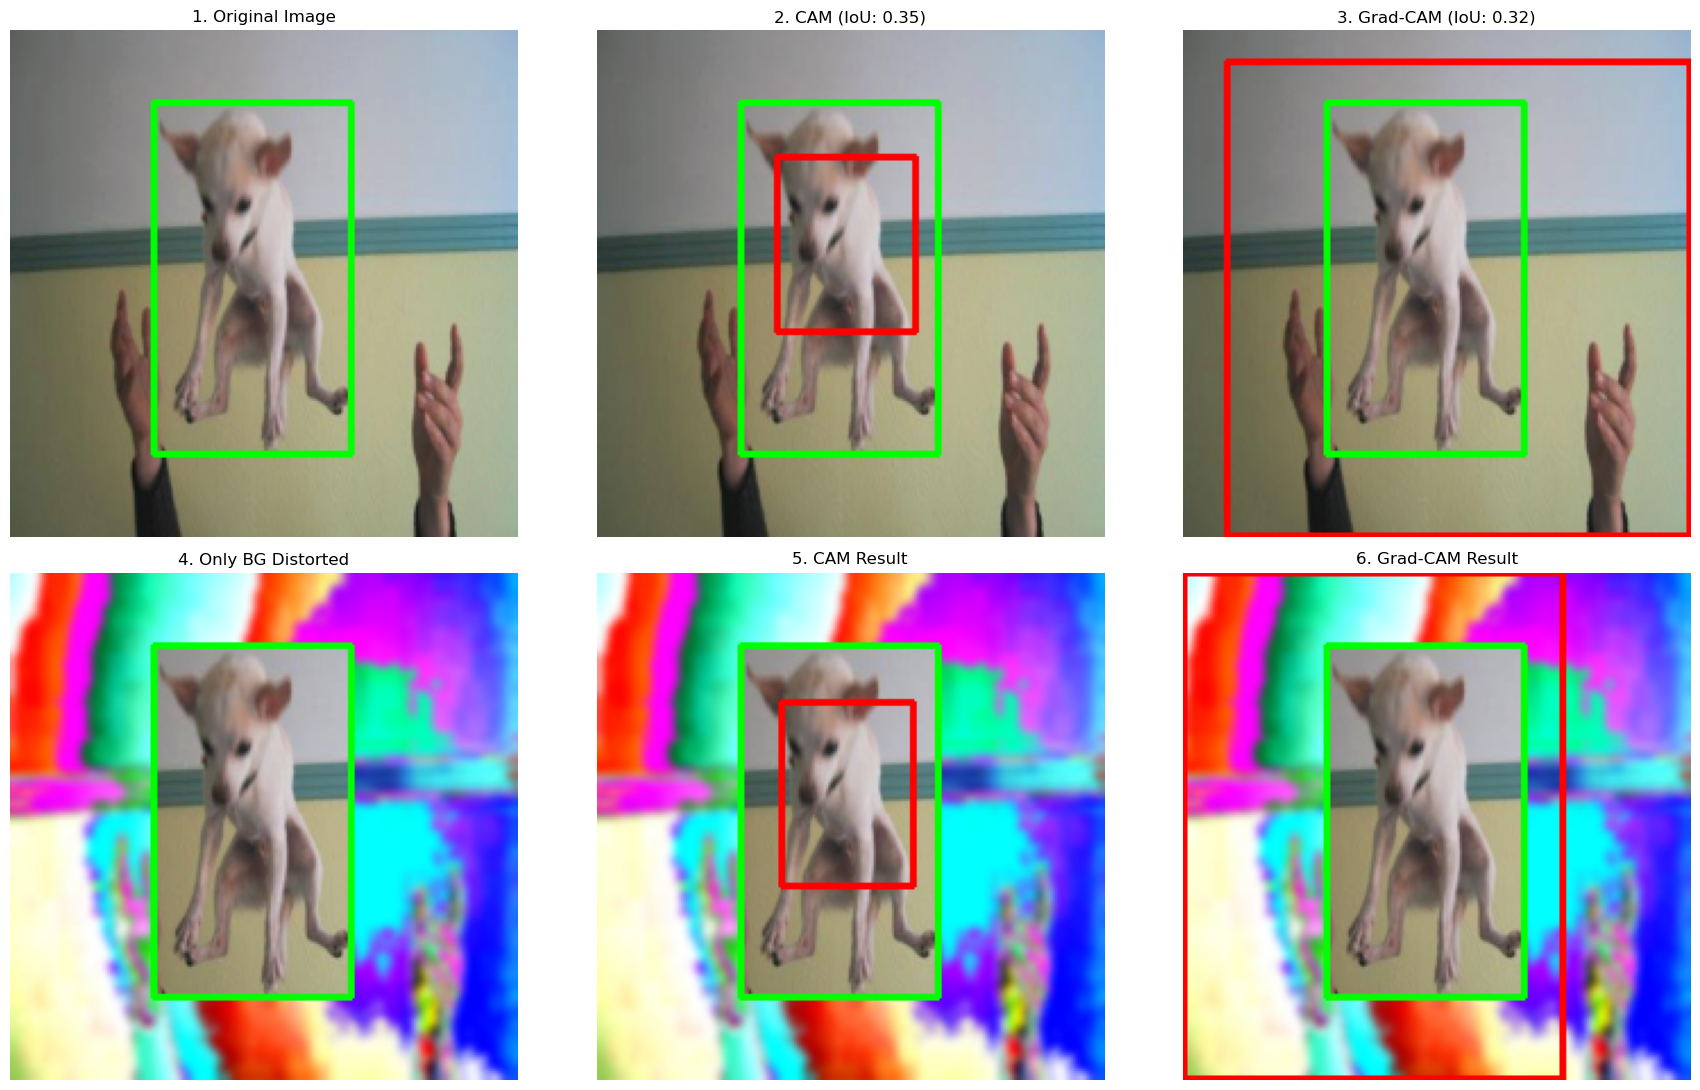

In [54]:
# --- 1. 바운딩 박스 시각화 함수 (Blue: AI, Green: 정답) ---
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    img_with_bbox = img.copy()
    
    # AI 인식 영역 (Blue) - 정수형 변환 필수
    if bbox is not None:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    # 사람이 그린 정답지 (Green)
    if ground_truth is not None:
        x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
        cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

# --- 2. 테스트 함수 (Unpacking 에러 방지를 위해 3개 그룹 반환) ---
def run_localization_test(img_tensor, target_bbox):
    # CAM/Grad-CAM 맵 생성 (layer4 기준)
    cam_map = generate_cam(model, img_tensor)
    grad_cam_map = generate_grad_cam(model, img_tensor, target_layer_name="layer3")
    
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    cam_resized = cv2.resize(cam_map, (w, h))
    grad_resized = cv2.resize(grad_cam_map, (w, h))
    
    # 바운딩 박스 추출 및 IoU 계산
    cam_bbox = get_bbox(cam_resized, threshold=0.3)
    grad_bbox = get_bbox(grad_resized, threshold=0.3)
    
    cam_iou = get_iou(cam_bbox, target_bbox)
    grad_iou = get_iou(grad_bbox, target_bbox)
    
    return (cam_iou, grad_iou), (cam_resized, grad_resized), (cam_bbox, grad_bbox)

# --- 3. 배경만 왜곡하는 함수 ---
def distort_background_only(image_tensor, bbox):
    confused_full = confusing_transform(image_tensor)
    x1, y1, x2, y2 = map(int, bbox)
    background_distorted = confused_full.clone()
    # 강아지 영역만 원본 데이터로 복구
    background_distorted[:, y1:y2, x1:x2] = image_tensor[:, y1:y2, x1:x2]
    return background_distorted

# --- 4. 데이터 준비 및 실험 실행 ---
image_tensor, label, ground_bbox = train_dataset[0] #
gt_int = [int(x) for x in ground_bbox]

# 배경만 왜곡된 텐서 생성
only_bg_confused_tensor = distort_background_only(image_tensor, ground_bbox)

# 시각화용 이미지 복원
orig_view = unnormalize(image_tensor)
confused_view = unnormalize(only_bg_confused_tensor)

# 모델 입력용 전송
sample_orig = image_tensor.unsqueeze(0).to(device)
sample_conf = only_bg_confused_tensor.unsqueeze(0).to(device)

# 테스트 실행 (반환값 3개 그룹)
orig_scores, orig_maps, orig_bboxes = run_localization_test(sample_orig, ground_bbox)
conf_scores, conf_maps, conf_bboxes = run_localization_test(sample_conf, ground_bbox)

# --- 5. 박스가 합성된 결과 이미지 생성 ---
# 원본 기준
res_orig_cam = visualize_both_bbox_on_image(orig_view, orig_bboxes[0], gt_int)
res_orig_grad = visualize_both_bbox_on_image(orig_view, orig_bboxes[1], gt_int)
# 배경 왜곡 기준
res_conf_input = visualize_both_bbox_on_image(confused_view, None, gt_int) # 입력이미지는 정답박스만
res_conf_cam = visualize_both_bbox_on_image(confused_view, conf_bboxes[0], gt_int)
res_conf_grad = visualize_both_bbox_on_image(confused_view, conf_bboxes[1], gt_int)

# --- 6. 최종 시각화 ---
print("\n" + "="*65)
print(f"{'Condition':<20} | {'CAM IoU':<15} | {'Grad-CAM IoU':<15}")
print("-"*65)
print(f"{'Original':<20} | {orig_scores[0]:.4f}          | {orig_scores[1]:.4f}")
print(f"{'Only BG Dist.':<20} | {conf_scores[0]:.4f}          | {conf_scores[1]:.4f}")
print("="*65 + "\n")

plt.figure(figsize=(18, 11))
titles = [
    "1. Original Image", f"2. CAM (IoU: {orig_scores[0]:.2f})", f"3. Grad-CAM (IoU: {orig_scores[1]:.2f})",
    "4. Only BG Distorted", "5. CAM Result", "6. Grad-CAM Result"
]
display_images = [
    visualize_both_bbox_on_image(orig_view, None, gt_int), res_orig_cam, res_orig_grad,
    res_conf_input, res_conf_cam, res_conf_grad
]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(display_images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3. 사진을 아주 작게 만들어보기(grad-cam 의 layer를 바꿔보며)

## grad-cam layer4

------------------------------------------------------------
CAM IoU (layer4): 0.0102 | Grad-CAM IoU (layer3): 0.0102
------------------------------------------------------------


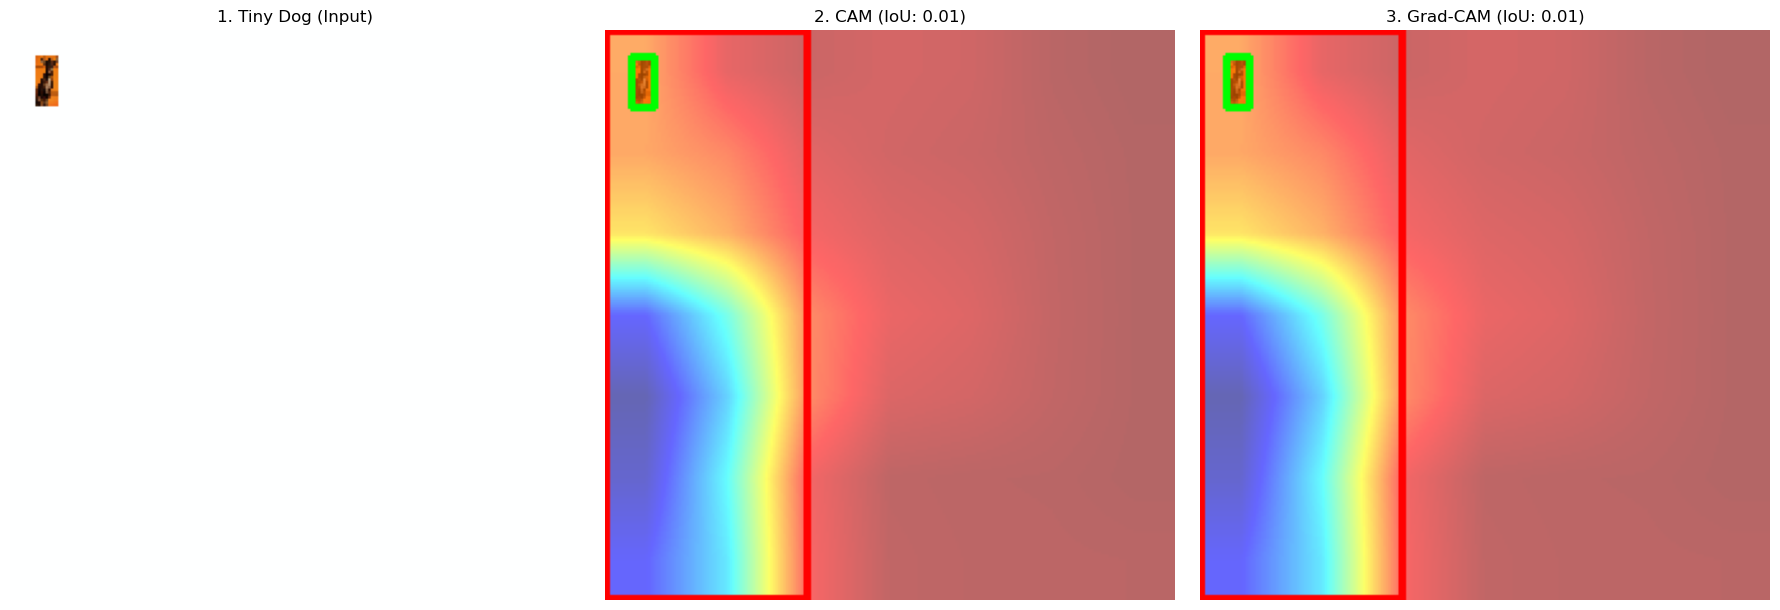

In [67]:
# --- 1. 히트맵 + 파란색 박스(AI) + 초록색 박스(정답) 통합 시각화 ---
def visualize_final_result(img_view, cam_map, ai_bbox, gt_bbox):
    # 히트맵 리사이즈 및 컬러 적용
    h, w = img_view.shape[:2]
    cam_resized = cv2.resize(cam_map, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    
    # 히트맵 합성 (6:4 비율)
    img_float = np.float32(img_view) / 255
    cam_img = 0.6 * (np.float32(heatmap) / 255) + 0.4 * img_float
    cam_img = np.uint8(255 * (cam_img / np.max(cam_img))).copy()

    # AI 예측 박스 (Blue: 255, 0, 0)
    if ai_bbox is not None:
        ax1, ay1, ax2, ay2 = map(int, ai_bbox)
        cv2.rectangle(cam_img, (ax1, ay1), (ax2, ay2), (255, 0, 0), 2)
    
    # 실제 정답 박스 (Green: 0, 255, 0)
    if gt_bbox is not None:
        gx1, gy1, gx2, gy2 = map(int, gt_bbox)
        cv2.rectangle(cam_img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 2)
        
    return cam_img

# --- 2. 강아지를 10%로 줄여서 '왼쪽 상단 구석'에 배치 ---
def shrink_dog_minimal(image_tensor, bbox, scale=0.1):
    C, H, W = image_tensor.shape
    x1, y1, x2, y2 = map(int, bbox)
    
    # 강아지 크롭 및 10% 리사이즈
    dog_crop = image_tensor[:, y1:y2, x1:x2]
    new_h, new_w = int((y2-y1) * scale), int((x2-x1) * scale)
    small_dog = F.interpolate(dog_crop.unsqueeze(0), size=(new_h, new_w), mode='bilinear').squeeze(0)
    
    # 흰색 배경 생성
    means = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(image_tensor.device)
    stds = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(image_tensor.device)
    white_bg = (torch.ones((C, H, W)).to(image_tensor.device) - means) / stds
    
    # 왼쪽 상단 구석(좌표 10, 10)에 배치
    white_bg[:, 10:10+new_h, 10:10+new_w] = small_dog
    new_bbox = (10, 10, 10 + new_w, 10 + new_h)
    
    return white_bg, new_bbox

# --- 3. 데이터 준비 및 실행 ---
image_tensor, label, ground_bbox = train_dataset[10] 
shrunk_tensor, new_gt_bbox = shrink_dog_minimal(image_tensor, ground_bbox, scale=0.1)

shrunk_view = unnormalize(shrunk_tensor)
sample_input = shrunk_tensor.unsqueeze(0).to(device)
gt_int = [int(x) for x in new_gt_bbox]

# --- 4. CAM vs Grad-CAM 정면 승부 ---
h, w = 224, 224
# CAM (layer4 - 7x7)
cam_map = generate_cam(model, sample_input)
cam_resized = cv2.resize(cam_map, (w, h))
c_box = get_bbox(cam_resized, threshold=0.2) # 작은 물체이므로 임계값을 살짝 낮춤
c_iou = get_iou(c_box, new_gt_bbox)

# Grad-CAM (layer3 - 14x14) 💡 정밀도를 위해 레이어 변경
grad_map = generate_grad_cam(model, sample_input, target_layer_name="layer4")
grad_resized = cv2.resize(grad_map, (w, h))
g_box = get_bbox(grad_resized, threshold=0.2)
g_iou = get_iou(g_box, new_gt_bbox)

# --- 5. 최종 시각화 ---
res_cam = visualize_final_result(shrunk_view, cam_resized, c_box, gt_int)
res_grad = visualize_final_result(shrunk_view, grad_resized, g_box, gt_int)

print("-" * 60)
print(f"CAM IoU (layer4): {c_iou:.4f} | Grad-CAM IoU (layer3): {g_iou:.4f}")
print("-" * 60)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(shrunk_view); plt.title("1. Tiny Dog (Input)"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(res_cam); plt.title(f"2. CAM (IoU: {c_iou:.2f})"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(res_grad); plt.title(f"3. Grad-CAM (IoU: {g_iou:.2f})"); plt.axis('off')
plt.tight_layout(); plt.show()

## grad-cam layer3

------------------------------------------------------------
CAM IoU (layer4): 0.0102 | Grad-CAM IoU (layer3): 0.0207
------------------------------------------------------------


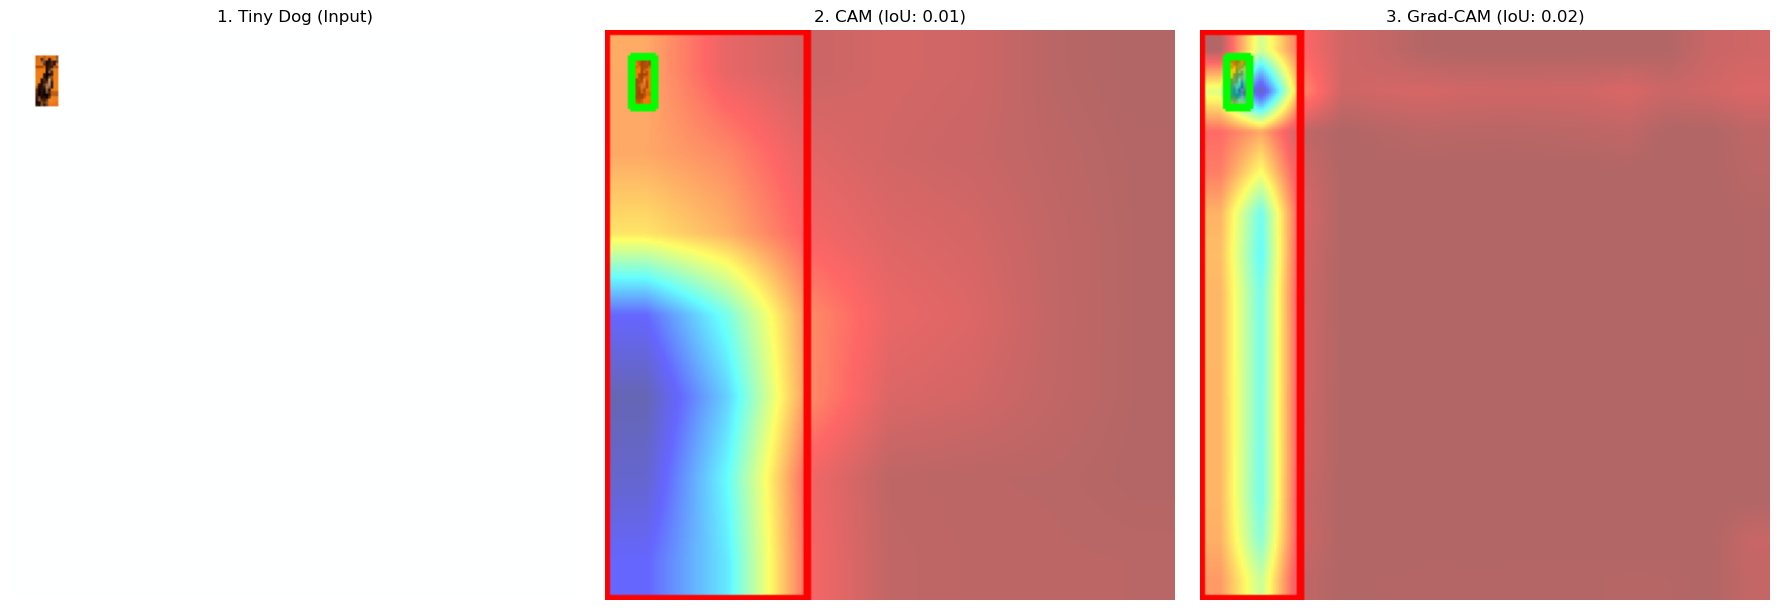

In [68]:
# --- 1. 히트맵 + 파란색 박스(AI) + 초록색 박스(정답) 통합 시각화 ---
def visualize_final_result(img_view, cam_map, ai_bbox, gt_bbox):
    # 히트맵 리사이즈 및 컬러 적용
    h, w = img_view.shape[:2]
    cam_resized = cv2.resize(cam_map, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    
    # 히트맵 합성 (6:4 비율)
    img_float = np.float32(img_view) / 255
    cam_img = 0.6 * (np.float32(heatmap) / 255) + 0.4 * img_float
    cam_img = np.uint8(255 * (cam_img / np.max(cam_img))).copy()

    # AI 예측 박스 (Blue: 255, 0, 0)
    if ai_bbox is not None:
        ax1, ay1, ax2, ay2 = map(int, ai_bbox)
        cv2.rectangle(cam_img, (ax1, ay1), (ax2, ay2), (255, 0, 0), 2)
    
    # 실제 정답 박스 (Green: 0, 255, 0)
    if gt_bbox is not None:
        gx1, gy1, gx2, gy2 = map(int, gt_bbox)
        cv2.rectangle(cam_img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 2)
        
    return cam_img

# --- 2. 강아지를 10%로 줄여서 '왼쪽 상단 구석'에 배치 ---
def shrink_dog_minimal(image_tensor, bbox, scale=0.1):
    C, H, W = image_tensor.shape
    x1, y1, x2, y2 = map(int, bbox)
    
    # 강아지 크롭 및 10% 리사이즈
    dog_crop = image_tensor[:, y1:y2, x1:x2]
    new_h, new_w = int((y2-y1) * scale), int((x2-x1) * scale)
    small_dog = F.interpolate(dog_crop.unsqueeze(0), size=(new_h, new_w), mode='bilinear').squeeze(0)
    
    # 흰색 배경 생성
    means = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(image_tensor.device)
    stds = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(image_tensor.device)
    white_bg = (torch.ones((C, H, W)).to(image_tensor.device) - means) / stds
    
    # 왼쪽 상단 구석(좌표 10, 10)에 배치
    white_bg[:, 10:10+new_h, 10:10+new_w] = small_dog
    new_bbox = (10, 10, 10 + new_w, 10 + new_h)
    
    return white_bg, new_bbox

# --- 3. 데이터 준비 및 실행 ---
image_tensor, label, ground_bbox = train_dataset[10] 
shrunk_tensor, new_gt_bbox = shrink_dog_minimal(image_tensor, ground_bbox, scale=0.1)

shrunk_view = unnormalize(shrunk_tensor)
sample_input = shrunk_tensor.unsqueeze(0).to(device)
gt_int = [int(x) for x in new_gt_bbox]

# --- 4. CAM vs Grad-CAM 정면 승부 ---
h, w = 224, 224
# CAM (layer4 - 7x7)
cam_map = generate_cam(model, sample_input)
cam_resized = cv2.resize(cam_map, (w, h))
c_box = get_bbox(cam_resized, threshold=0.2) # 작은 물체이므로 임계값을 살짝 낮춤
c_iou = get_iou(c_box, new_gt_bbox)

# Grad-CAM (layer3 - 14x14) 💡 정밀도를 위해 레이어 변경
grad_map = generate_grad_cam(model, sample_input, target_layer_name="layer3")
grad_resized = cv2.resize(grad_map, (w, h))
g_box = get_bbox(grad_resized, threshold=0.2)
g_iou = get_iou(g_box, new_gt_bbox)

# --- 5. 최종 시각화 ---
res_cam = visualize_final_result(shrunk_view, cam_resized, c_box, gt_int)
res_grad = visualize_final_result(shrunk_view, grad_resized, g_box, gt_int)

print("-" * 60)
print(f"CAM IoU (layer4): {c_iou:.4f} | Grad-CAM IoU (layer3): {g_iou:.4f}")
print("-" * 60)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(shrunk_view); plt.title("1. Tiny Dog (Input)"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(res_cam); plt.title(f"2. CAM (IoU: {c_iou:.2f})"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(res_grad); plt.title(f"3. Grad-CAM (IoU: {g_iou:.2f})"); plt.axis('off')
plt.tight_layout(); plt.show()

## 4. 강아지를 부분적으로 가릴 경우

## grad-cam layer4

-----------------------------------------------------------------
채점 결과 (IoU) | CAM: 0.4780 | Grad-CAM: 0.4780
-----------------------------------------------------------------


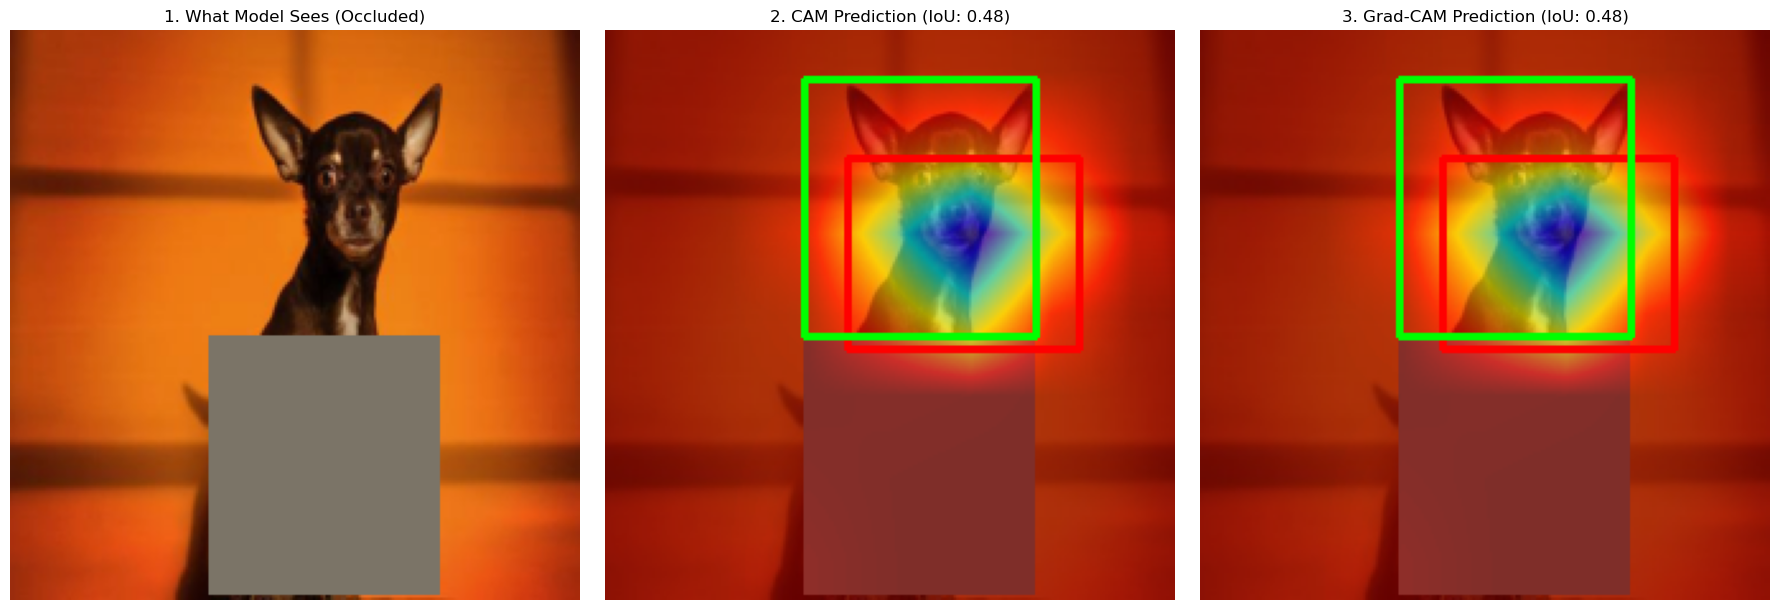

In [74]:
# --- 1. [통합] 히트맵 + AI 박스 + 정답 박스 시각화 함수 ---
def visualize_occlusion_result(img_view, cam_map, ai_bbox, gt_bbox):
    # 히트맵 생성 및 원본 이미지와 합성 (6:4 비율)
    h, w = img_view.shape[:2]
    cam_resized = cv2.resize(cam_map, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    
    img_float = np.float32(img_view) / 255
    cam_img = 0.6 * (np.float32(heatmap) / 255) + 0.4 * img_float
    result_img = np.uint8(255 * (cam_img / np.max(cam_img))).copy() #

    # AI 예측 영역 (Blue: 255, 0, 0)
    if ai_bbox is not None:
        ax1, ay1, ax2, ay2 = map(int, ai_bbox)
        cv2.rectangle(result_img, (ax1, ay1), (ax2, ay2), (255, 0, 0), 2)
    
    # 실제 정답 영역 (Green: 0, 255, 0)
    if gt_bbox is not None:
        gx1, gy1, gx2, gy2 = map(int, gt_bbox)
        cv2.rectangle(result_img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 2)
        
    return result_img

# --- 2. 실험 데이터 준비 (사용자 코드 유지) ---
image_tensor, label, ground_bbox = train_dataset[10]
occluded_tensor, visible_gt = create_occluded_input(image_tensor, ground_bbox)
input_img = occluded_tensor.unsqueeze(0).to(device)
occluded_view = unnormalize(occluded_tensor)
gt_int = [int(x) for x in visible_gt]

# --- 3. 블라인드 테스트 수행 (박스 좌표도 반환하도록 수정) ---
def run_blind_inference_with_bbox(model, img_tensor, target_bbox):
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    
    # CAM (layer4)
    cam_map = generate_cam(model, img_tensor)
    cam_resized = cv2.resize(cam_map, (w, h))
    c_box = get_bbox(cam_resized, threshold=0.3)
    c_iou = get_iou(c_box, target_bbox)
    
    # Grad-CAM (layer3 추천 혹은 코드 유지)
    grad_map = generate_grad_cam(model, img_tensor, target_layer_name="layer4")
    grad_resized = cv2.resize(grad_map, (w, h))
    g_box = get_bbox(grad_resized, threshold=0.3)
    g_iou = get_iou(g_box, target_bbox)
    
    return (c_iou, g_iou), (cam_resized, grad_resized), (c_box, g_box)

# 추론 실행
scores, maps, bboxes = run_blind_inference_with_bbox(model, input_img, visible_gt)

# --- 4. 최종 통합 시각화 ---
# 히트맵 + 파란색(AI) + 초록색(정답) 합성
res_cam = visualize_occlusion_result(occluded_view, maps[0], bboxes[0], gt_int)
res_grad = visualize_occlusion_result(occluded_view, maps[1], bboxes[1], gt_int)

print("-" * 65)
print(f"채점 결과 (IoU) | CAM: {scores[0]:.4f} | Grad-CAM: {scores[1]:.4f}")
print("-" * 65)

plt.figure(figsize=(18, 6))

# 1. 모델이 본 입력 이미지
plt.subplot(1, 3, 1)
plt.imshow(occluded_view)
plt.title("1. What Model Sees (Occluded)")
plt.axis('off')

# 2. CAM 히트맵 + 박스
plt.subplot(1, 3, 2)
plt.imshow(res_cam)
plt.title(f"2. CAM Prediction (IoU: {scores[0]:.2f})")
plt.axis('off')

# 3. Grad-CAM 히트맵 + 박스
plt.subplot(1, 3, 3)
plt.imshow(res_grad)
plt.title(f"3. Grad-CAM Prediction (IoU: {scores[1]:.2f})")
plt.axis('off')

plt.tight_layout()
plt.show()

## grad-cam layer3

-----------------------------------------------------------------
채점 결과 (IoU) | CAM: 0.4780 | Grad-CAM: 0.2277
-----------------------------------------------------------------


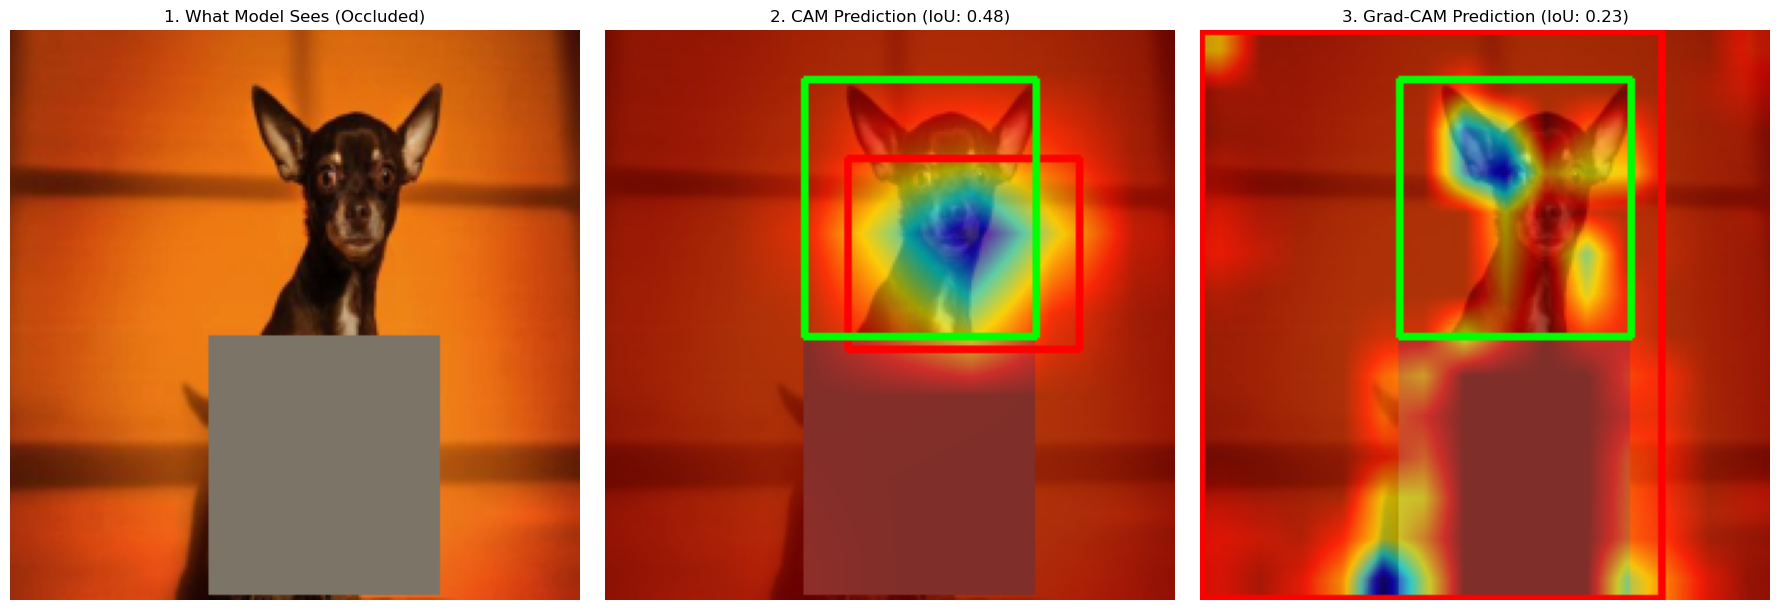

In [75]:
# --- 1. [통합] 히트맵 + AI 박스 + 정답 박스 시각화 함수 ---
def visualize_occlusion_result(img_view, cam_map, ai_bbox, gt_bbox):
    # 히트맵 생성 및 원본 이미지와 합성 (6:4 비율)
    h, w = img_view.shape[:2]
    cam_resized = cv2.resize(cam_map, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    
    img_float = np.float32(img_view) / 255
    cam_img = 0.6 * (np.float32(heatmap) / 255) + 0.4 * img_float
    result_img = np.uint8(255 * (cam_img / np.max(cam_img))).copy() #

    # AI 예측 영역 (Blue: 255, 0, 0)
    if ai_bbox is not None:
        ax1, ay1, ax2, ay2 = map(int, ai_bbox)
        cv2.rectangle(result_img, (ax1, ay1), (ax2, ay2), (255, 0, 0), 2)
    
    # 실제 정답 영역 (Green: 0, 255, 0)
    if gt_bbox is not None:
        gx1, gy1, gx2, gy2 = map(int, gt_bbox)
        cv2.rectangle(result_img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 2)
        
    return result_img

# --- 2. 실험 데이터 준비 (사용자 코드 유지) ---
image_tensor, label, ground_bbox = train_dataset[10]
occluded_tensor, visible_gt = create_occluded_input(image_tensor, ground_bbox)
input_img = occluded_tensor.unsqueeze(0).to(device)
occluded_view = unnormalize(occluded_tensor)
gt_int = [int(x) for x in visible_gt]

# --- 3. 블라인드 테스트 수행 (박스 좌표도 반환하도록 수정) ---
def run_blind_inference_with_bbox(model, img_tensor, target_bbox):
    h, w = img_tensor.shape[2], img_tensor.shape[3]
    
    # CAM (layer4)
    cam_map = generate_cam(model, img_tensor)
    cam_resized = cv2.resize(cam_map, (w, h))
    c_box = get_bbox(cam_resized, threshold=0.3)
    c_iou = get_iou(c_box, target_bbox)
    
    # Grad-CAM (layer3 추천 혹은 코드 유지)
    grad_map = generate_grad_cam(model, img_tensor, target_layer_name="layer3")
    grad_resized = cv2.resize(grad_map, (w, h))
    g_box = get_bbox(grad_resized, threshold=0.3)
    g_iou = get_iou(g_box, target_bbox)
    
    return (c_iou, g_iou), (cam_resized, grad_resized), (c_box, g_box)

# 추론 실행
scores, maps, bboxes = run_blind_inference_with_bbox(model, input_img, visible_gt)

# --- 4. 최종 통합 시각화 ---
# 히트맵 + 파란색(AI) + 초록색(정답) 합성
res_cam = visualize_occlusion_result(occluded_view, maps[0], bboxes[0], gt_int)
res_grad = visualize_occlusion_result(occluded_view, maps[1], bboxes[1], gt_int)

print("-" * 65)
print(f"채점 결과 (IoU) | CAM: {scores[0]:.4f} | Grad-CAM: {scores[1]:.4f}")
print("-" * 65)

plt.figure(figsize=(18, 6))

# 1. 모델이 본 입력 이미지
plt.subplot(1, 3, 1)
plt.imshow(occluded_view)
plt.title("1. What Model Sees (Occluded)")
plt.axis('off')

# 2. CAM 히트맵 + 박스
plt.subplot(1, 3, 2)
plt.imshow(res_cam)
plt.title(f"2. CAM Prediction (IoU: {scores[0]:.2f})")
plt.axis('off')

# 3. Grad-CAM 히트맵 + 박스
plt.subplot(1, 3, 3)
plt.imshow(res_grad)
plt.title(f"3. Grad-CAM Prediction (IoU: {scores[1]:.2f})")
plt.axis('off')

plt.tight_layout()
plt.show()

## 📝 Object Localization 성능 비교 실험 회고

본 실험에서는 **CAM**과 **Grad-CAM** 기법을 활용하여 다양한 이미지 변형 조건에서의 객체 검출(Localization) 성능을 IoU 지표로 비교 분석하였습니다.

---

### 1. CAM vs. Grad-CAM(Layer 4) 비교
* **결과**: 거의 모든 실험 조건에서 두 기법 간의 성능 차이가 거의 나타나지 않았습니다.
* **분석**: ResNet50처럼 GAP(Global Average Pooling)를 사용하는 모델 구조에서는 마지막 레이어에 대한 Grad-CAM 가중치가 CAM 가중치와 수학적으로 동일하게 수렴하기 때문입니다.

### 2. Grad-CAM(Layer 3) 기반 상세 실험 분석

#### ① 전체 이미지의 심각한 왜곡 (Severe Distortion)
* **결과**: Grad-CAM(L3)이 CAM보다 오히려 낮은 성능을 보였습니다.
* **추론**: Layer 3는 물체의 세부적인 특징(눈, 코, 입 등)에 집중하는 경향이 있습니다. 이미지 전체가 왜곡되면 이러한 국소적인 특징 신호가 노이즈에 묻혀 파괴되지만, Layer 4를 사용하는 CAM은 해상도는 낮아도 물체의 전체적인 형태(Global Context)를 유지하여 위치를 더 잘 보존한 것으로 판단됩니다.

#### ② 배경만 심각한 왜곡 (Background Mod Only)
* **결과**: Grad-CAM(L3)의 성능이 소폭 상승하며 CAM을 앞섰습니다.
* **추론**: 강아지 객체는 선명하고 배경만 노이즈가 있는 상황에서는 고해상도($14 \times 14$)를 가진 Layer 3가 배경 노이즈를 효과적으로 배제하고 객체에만 더 날카롭게 활성화될 수 있었기 때문입니다.

#### ③ 초소형 객체 검출 (Tiny Dog)
* **결과**: Grad-CAM(L3)의 성능이 CAM보다 압도적으로 우수했습니다.
* **추론**: **해상도의 차이**가 핵심입니다. 마지막 레이어($7 \times 7$)를 쓰는 CAM은 작은 물체를 표현하기에 픽셀이 너무 뭉툭하여 위치가 크게 번지지만, Layer 3($14 \times 14$)는 4배 더 정밀한 해상도로 구석에 있는 작은 객체를 정확히 짚어낼 수 있었습니다.


#### ④ 객체 일부 가리기 (Partial Occlusion)
* **결과**: CAM의 성능이 Grad-CAM(L3)보다 월등히 좋았습니다.
* **추론**: **IoU 지표의 특성**과 관련이 있습니다. Grad-CAM(L3)은 가려지지 않은 특정 포인트(예: 귀,다리)에 너무 예민하게 반응하여 박스가 너무 크게 그려진 반면, CAM은 특유의 뭉툭한 활성화 범위 를 제외한 "강아지 영역"으로 잡아내어 정답 박스와의 겹침 면적을 넓혔기 때문입니다.


---

### 3. 최종 결론
실험 결과, 기법의 우열보다는 **대상 객체의 크기와 환경 노이즈**에 따라 적절한 레이어를 선택하는 것이 localization 성능의 핵심임을 확인했습니다. 정밀한 검출이 필요할 때는 중간 레이어(L3)를, 객체가 가려지거나 왜곡이 심해 맥락 파악이 중요할 때는 마지막 레이어(L4)를 활용하는 전략이 유효함을 학습하였습니다.